np.float64(1.4376428430358787)

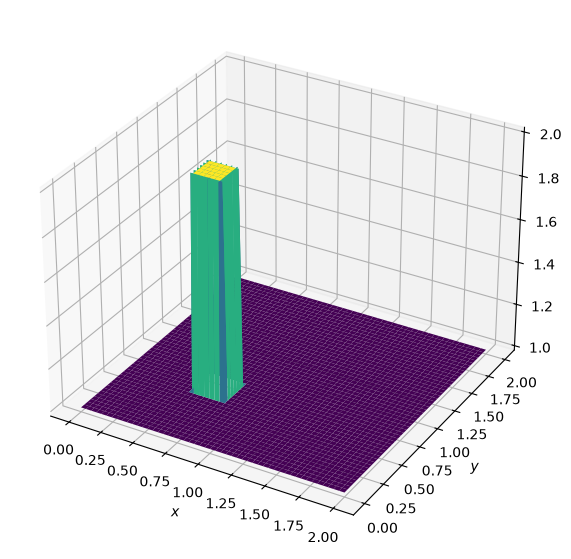

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import clear_output

nx = 101
ny = 101
nt = 100

dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
sigma = 0.2
dt = sigma * dx

x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

uv = np.ones((ny, nx, 2))
# uv[int(0.25 / dy):int(0.50 / dy),int(0.25 / dx):int(0.50 / dx)] = [5, 5]
uv[int(0.55 / dy):int(0.80 / dy),int(0.55 / dx):int(0.80 / dx)] = [2, 2]

fig = plt.figure(figsize=(11, 7), dpi=100)
ax = fig.add_subplot(projection='3d')
X, Y = np.meshgrid(x, y)
ax.plot_surface(X, Y, uv[:, :, 0], cmap=cm.viridis, rstride=2, cstride=2)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

np.mean(np.sqrt(uv[:, :, 0]**2 + uv[:, :, 1]**2))

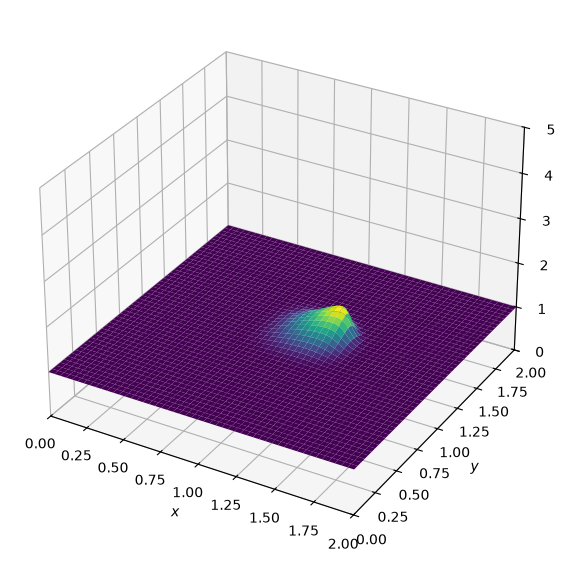

np.float64(1.4307171626260662)

In [2]:
for n in range(nt):
    uvn = uv.copy()

    uv[1:, 1:, 0] = uvn[1:, 1:, 0] - uvn[1:, 1:, 0] * dt / dx * (uvn[1:, 1:, 0] - uvn[1:, :-1, 0]) - uvn[1:, 1:, 1] * dt / dy * (uvn[1:, 1:, 0] - uvn[:-1, 1:, 0])
    uv[1:, 1:, 1] = uvn[1:, 1:, 1] - uvn[1:, 1:, 0] * dt / dx * (uvn[1:, 1:, 1] - uvn[1:, :-1, 1]) - uvn[1:, 1:, 1] * dt / dy * (uvn[1:, 1:, 1] - uvn[:-1, 1:, 1])
        
    uv[0, :] = [1, 1]
    uv[-1, :] = [1, 1]
    uv[:, 0] = [1, 1]
    uv[:, -1] = [1, 1]

    clear_output(True)
    
    fig = plt.figure(figsize=(11, 7), dpi=100)
    ax = fig.add_subplot(projection='3d')
    X, Y = np.meshgrid(x, y)
    ax.plot_surface(X, Y, uv[:, :, 0], cmap=cm.viridis, rstride=2, cstride=2)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.axis([0, 2, 0, 2, 0, 5])

    # velocity = np.sqrt(uv[:, :, 0]**2 + uv[:, :, 1]**2)
    # fig, ax = plt.subplots(figsize=(9, 7), dpi=100)
    # ax.set_facecolor('black')
    # sub = 4
    # quiv = ax.quiver(X[::sub, ::sub], Y[::sub, ::sub], 
    #                 uv[::sub, ::sub, 0], uv[::sub, ::sub, 1], 
    #                 velocity[::sub, ::sub],
    #                 scale=50, 
    #                 cmap='plasma', 
    #                 pivot='middle')

    # fig.colorbar(quiv, label='Velocity Magnitude')

    # ax.set_xlabel('$x$')
    # ax.set_ylabel('$y$')
    # ax.set_title('2D Convection Velocity Vector Field')

    plt.pause(0.0001)

np.mean(np.sqrt(uv[:, :, 0]**2 + uv[:, :, 1]**2))